# WCS 08 — Regional Plate-Solve Comparison

**Motivation:** Prior diagnostics show that the full-field WCS fits the centre well (median nearest-reference distance ≈ 12 px) but is much poorer on the left (≈ 49 px) and right (≈ 72 px).  This notebook tests whether the poor edge alignment is caused by the global WCS being unable to simultaneously fit the whole ≈70° FOV, or whether something else is at play.

**Method:** Submit separate astrometry.net solves using only the sources from each spatial sub-region of the detector, while keeping the full image width/height in every submission.  If a regional solve improves alignment in its own region while making the opposite side worse, that is strong evidence of unmodelled wide-field distortion.

**New API:** uses `platesolve_xylist(xs, ys, image_width, image_height, ...)` from `extractor.platesolve` — identical to `platesolve()` but accepts a pre-built source list instead of extracting from the image.

**Regions tested:**
- FULL, LEFT_HALF, RIGHT_HALF
- LEFT_THIRD, CENTER_THIRD, RIGHT_THIRD
- LEFT_PLUS_CENTER, CENTER_PLUS_RIGHT

Results are cached aggressively; re-running the notebook after the first successful solve is fast.

In [1]:
import sys
from pathlib import Path
import warnings
import pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

from extractor.platesolve import platesolve_xylist, has_sip, wcs_summary
from astropy.io import fits as afits
from astropy.wcs import WCS
from astropy.table import Table
from astropy.coordinates import SkyCoord
import astropy.units as u

OUT_DIR     = ROOT / 'out' / 'wcs_diagnostics'
PROD_DIR    = OUT_DIR / 'products'
REGIONAL_DIR = OUT_DIR / 'regional_solves'
CACHE       = OUT_DIR / 'platesolve_result.pkl'
REGIONAL_DIR.mkdir(parents=True, exist_ok=True)

if not CACHE.exists():
    raise FileNotFoundError(f'Run wcs_01 first to create {CACHE}')
with open(CACHE, 'rb') as f:
    full_result = pickle.load(f)

# Original FITS header (for merging into regional results)
fits_path = sorted((ROOT / 'data').glob('*.fit'))[0]
with afits.open(fits_path) as hdul:
    image          = hdul[0].data.astype(float)
    original_header = hdul[0].header.copy()
h, w = image.shape

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    full_wcs = WCS(full_result.header)

cd11 = full_result.header.get('CD1_1', 0)
cd21 = full_result.header.get('CD2_1', 0)
plate_scale = np.hypot(cd11, cd21) * 3600  # arcsec/px

# Full-field WCS centre in sky coordinates
cx, cy = w / 2.0, h / 2.0
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    center_ra, center_dec = full_wcs.pixel_to_world_values(cx, cy)

print(f'Image         : {fits_path.name}  {w}x{h} px')
print(f'Plate scale   : {plate_scale:.2f} arcsec/px')
print(f'Full-WCS centre : RA={center_ra:.4f} deg  Dec={center_dec:.4f} deg')
print(f'Regional dir  : {REGIONAL_DIR}')
print()
print(wcs_summary(full_result.header))

Image         : fuji6_asi178_100_15s.fit  3096x2080 px
Plate scale   : 80.93 arcsec/px
Full-WCS centre : RA=113.4038 deg  Dec=30.3918 deg
Regional dir  : C:\Users\bassd\Research\Spectra Angle\spectrangle\out\wcs_diagnostics\regional_solves

  CTYPE1  : RA---TAN-SIP
  CTYPE2  : DEC--TAN-SIP
  CRVAL1  : 120.61262
  CRVAL2  : 29.788056
  CRPIX1  : 1286.8585
  CRPIX2  : 1140.5638
  CD1_1   : -0.0218561
  CD1_2   : 0.00514579
  CD2_1   : -0.00525836
  CD2_2   : -0.0219369
  SIP     : yes (order 2)


In [2]:
def _load_tbl(path, label):
    p = Path(path)
    if not p.exists():
        print(f'  {label}: NOT FOUND')
        return None
    with afits.open(p) as hdul:
        hdu = next((h for h in hdul
                    if isinstance(h, (afits.BinTableHDU, afits.TableHDU))), None)
        if hdu is None:
            return None
        t = Table(hdu.data)
    print(f'  {label}: {len(t)} rows | {t.colnames}')
    return t

def gcol(tbl, *names):
    if tbl is None: return None
    low = {c.strip().lower(): c for c in tbl.colnames}
    for n in names:
        k = low.get(n.strip().lower())
        if k is not None:
            return np.asarray(tbl[k], dtype=float)
    return None

def _fb(tbl, attr):
    if tbl is not None: return tbl
    t = getattr(full_result, attr, None)
    if t is not None: print(f'  {attr}: in-memory fallback ({len(t)} rows)')
    return t

print('Loading product tables:')
axy_tbl   = _fb(_load_tbl(PROD_DIR / 'axy.fits',         'axy      '), 'axy_table')
corr_tbl  = _fb(_load_tbl(PROD_DIR / 'corr.fits',        'corr     '), 'corr_table')
rdls_tbl  = _fb(_load_tbl(PROD_DIR / 'rdls.fits',        'rdls     '), 'rdls_table')
imgrd_tbl = _fb(_load_tbl(PROD_DIR / 'image-radec.fits', 'image_rd '), 'image_radec_table')

rdls_ra  = gcol(rdls_tbl, 'RA')
rdls_dec = gcol(rdls_tbl, 'DEC')
axy_x    = gcol(axy_tbl,  'X')
axy_y    = gcol(axy_tbl,  'Y')

Loading product tables:
  axy      : 255 rows | ['X', 'Y']
  corr     : 48 rows | ['field_x', 'field_y', 'field_ra', 'field_dec', 'index_x', 'index_y', 'index_ra', 'index_dec', 'index_id', 'field_id', 'match_weight', 'MAG_BT', 'MAG_VT', 'MAG_HP', 'MAG']
  rdls     : 179 rows | ['MAG_BT', 'MAG_VT', 'MAG_HP', 'MAG', 'RA', 'DEC']
  image_rd : 255 rows | ['ra', 'dec', 'x', 'y']


Source list: 255 sources  (from result.detected_x/y)
  x range: [67, 2821]
  y range: [14, 2072]


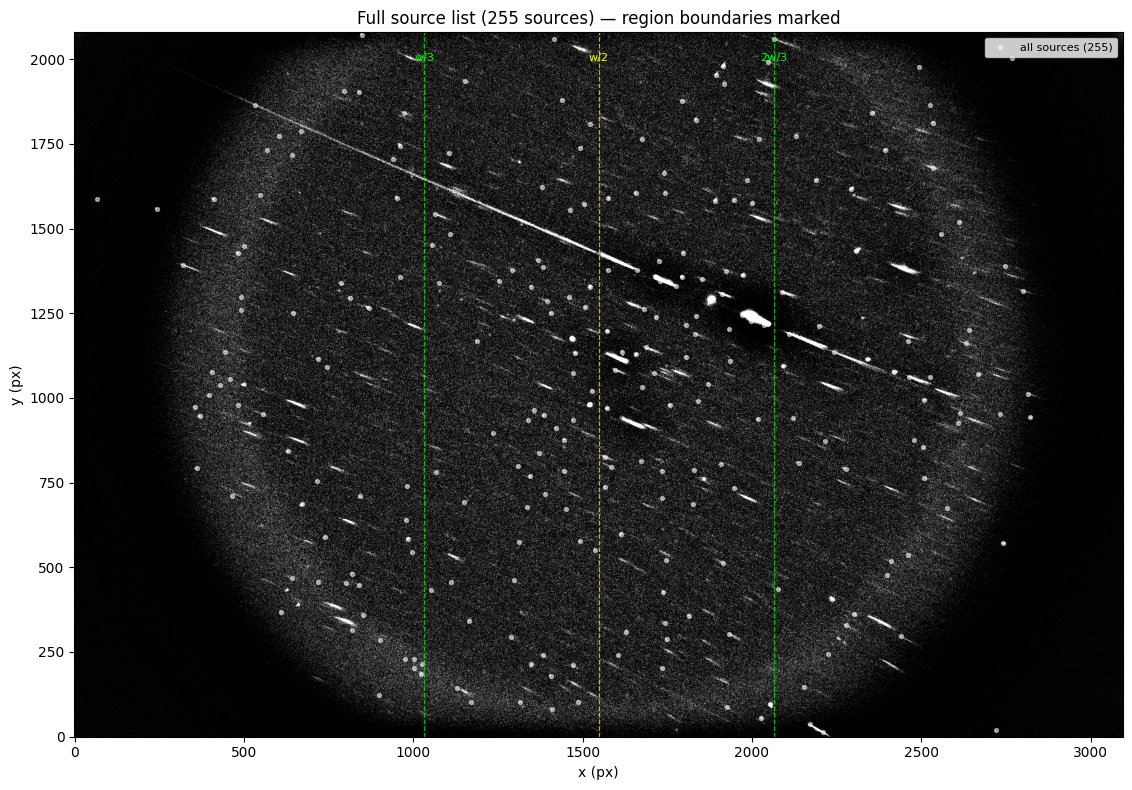

In [3]:
# Use the same source list that was originally submitted for the full solve.
# Prefer result.detected_x/y; fall back to axy.fits X/Y.
if len(full_result.detected_x) > 0:
    src_x = full_result.detected_x.copy()
    src_y = full_result.detected_y.copy()
    src_origin = 'result.detected_x/y'
elif axy_x is not None:
    src_x = axy_x.copy()
    src_y = axy_y.copy()
    src_origin = 'axy.fits X/Y'
else:
    raise RuntimeError('No source list available.')

print(f'Source list: {len(src_x)} sources  (from {src_origin})')
print(f'  x range: [{src_x.min():.0f}, {src_x.max():.0f}]')
print(f'  y range: [{src_y.min():.0f}, {src_y.max():.0f}]')

# Plot sources over image with region boundaries
bg   = gaussian_filter(image.astype(np.float32), sigma=50.0)
proc = np.clip(image.astype(np.float32) - bg, 0.0, None)
lo, hi = np.percentile(proc[np.isfinite(proc)], [0.5, 99.5])
disp = np.arcsinh(np.clip(proc, lo, hi))

fig, ax = plt.subplots(figsize=(14, 8))
ax.set_facecolor('#111')
ax.imshow(disp, origin='lower', cmap='gray',
          vmin=np.arcsinh(lo), vmax=np.arcsinh(hi), aspect='equal')
ax.scatter(src_x, src_y, s=8, c='white', alpha=0.5, label=f'all sources ({len(src_x)})')
for xv, lbl, col in [(w/3,'w/3','lime'), (w/2,'w/2','yellow'), (2*w/3,'2w/3','lime')]:
    ax.axvline(xv, color=col, lw=0.9, linestyle='--', alpha=0.7)
    ax.text(xv, h*0.97, lbl, color=col, ha='center', va='top', fontsize=8)
ax.set_xlim(-0.5, w-0.5); ax.set_ylim(-0.5, h-0.5)
ax.set_xlabel('x (px)'); ax.set_ylabel('y (px)')
ax.set_title(f'Full source list ({len(src_x)} sources) — region boundaries marked')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / 'wcs08_region_source_subsets.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
REGION_MASKS = {
    'FULL':               np.ones(len(src_x), dtype=bool),
    'LEFT_HALF':          src_x < w / 2,
    'RIGHT_HALF':         src_x >= w / 2,
    'LEFT_THIRD':         src_x < w / 3,
    'CENTER_THIRD':       (src_x >= w / 3) & (src_x < 2 * w / 3),
    'RIGHT_THIRD':        src_x >= 2 * w / 3,
    'LEFT_PLUS_CENTER':   src_x < 2 * w / 3,
    'CENTER_PLUS_RIGHT':  src_x >= w / 3,
}

print(f'Region source counts (out of {len(src_x)} total):')
print(f"{'Region':20s}  {'N_src':>6}  {'x_range':>22}")
print('-' * 55)
for name, mask in REGION_MASKS.items():
    xs_r = src_x[mask]
    xr = f'[{xs_r.min():.0f}, {xs_r.max():.0f}]' if len(xs_r) > 0 else 'empty'
    flag = '  ** FEW **' if len(xs_r) < 15 else ''
    print(f'{name:20s}  {mask.sum():>6}  {xr:>22}{flag}')

Region source counts (out of 255 total):
Region                 N_src                 x_range
-------------------------------------------------------
FULL                     255              [67, 2821]
LEFT_HALF                125              [67, 1538]
RIGHT_HALF               130            [1565, 2821]
LEFT_THIRD                63              [67, 1027]
CENTER_THIRD             137            [1053, 2055]
RIGHT_THIRD               55            [2066, 2821]
LEFT_PLUS_CENTER         200              [67, 2055]
CENTER_PLUS_RIGHT        192            [1053, 2821]


In [5]:
# Hints passed to every regional solve.
# Center RA/Dec from the full solution narrows the search to the correct field.
# A large radius is used because the FOV is ~70 deg and regional source lists
# may have fewer constraints.
# Scale hints use the known plate scale with a generous tolerance.

SOLVE_HINTS = {
    'center_ra':   float(center_ra),
    'center_dec':  float(center_dec),
    'radius':      25.0,              # search radius in degrees
    'scale_lower': plate_scale * 0.70,
    'scale_upper': plate_scale * 1.30,
    'scale_units': 'arcsecperpix',
}

print('Solve hints for all regional submissions:')
for k, v in SOLVE_HINTS.items():
    print(f'  {k:15s}: {v}')

Solve hints for all regional submissions:
  center_ra      : 113.4037668027565
  center_dec     : 30.391818434111926
  radius         : 25.0
  scale_lower    : 56.64906865993985
  scale_upper    : 105.20541322560258
  scale_units    : arcsecperpix


In [7]:
# FULL uses the already-cached full result — no re-submission needed.
regional_results = {'FULL': full_result}

for region_name, mask in REGION_MASKS.items():
    if region_name == 'FULL':
        continue  # already loaded above

    rxs = src_x[mask]
    rys = src_y[mask]

    if len(rxs) < 10:
        print(f'\n--- {region_name}: SKIPPED ({len(rxs)} sources < 10 minimum) ---')
        regional_results[region_name] = None
        continue

    cache_path = REGIONAL_DIR / region_name / 'result.pkl'
    save_dir   = REGIONAL_DIR / region_name / 'products'

    print(f'\n--- {region_name} ({len(rxs)} sources) ---')
    res = platesolve_xylist(
        rxs, rys, w, h,
        original_header=original_header,
        hints=SOLVE_HINTS,
        cache=cache_path,
        fetch_products=True,
        save_products_dir=save_dir,
        verbose=True,
    )
    regional_results[region_name] = res
    if res is None:
        print(f'  {region_name}: SOLVE FAILED')

print('\nAll regional solves complete.')
print(f'Successes : {sum(v is not None for v in regional_results.values())} / {len(regional_results)}')


--- LEFT_HALF (125 sources) ---
Loading cached result from result.pkl

--- RIGHT_HALF (130 sources) ---
Loading cached result from result.pkl

--- LEFT_THIRD (63 sources) ---
Logged in to nova.astrometry.net
Submitting 63 sources  (3096x2080 frame).
Source list uploaded (submission 14947017)
Waiting for job assignment. job 15782944
Solving. FAILED.
  LEFT_THIRD: SOLVE FAILED

--- CENTER_THIRD (137 sources) ---
Loading cached result from result.pkl

--- RIGHT_THIRD (55 sources) ---
Logged in to nova.astrometry.net
Submitting 55 sources  (3096x2080 frame).
Source list uploaded (submission 14947021)
Waiting for job assignment job 15782948
Solving. FAILED.
  RIGHT_THIRD: SOLVE FAILED

--- LEFT_PLUS_CENTER (200 sources) ---
Loading cached result from result.pkl

--- CENTER_PLUS_RIGHT (192 sources) ---
Logged in to nova.astrometry.net
Submitting 192 sources  (3096x2080 frame).
Source list uploaded (submission 14947024)
Waiting for job assignment job 15782952
Solving. solved!
WCS header fetc

In [8]:
def _wcs_center(res):
    """Return (ra, dec, north_angle_deg, scale_as_px) at image centre."""
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        wobj = WCS(res.header)
        ra, dec = wobj.pixel_to_world_values(cx, cy)
        # North angle: direction of +Dec in pixel space
        step = 0.05  # deg
        px_n, py_n = wobj.world_to_pixel_values(ra, dec + step)
        north_ang = float(np.degrees(np.arctan2(py_n - cy, px_n - cx)))
        # Local plate scale
        ra2, dec2 = wobj.pixel_to_world_values(cx + 10, cy)
        s1 = SkyCoord(ra=ra*u.deg, dec=dec*u.deg)
        s2 = SkyCoord(ra=ra2*u.deg, dec=dec2*u.deg)
        scale = float(s1.separation(s2).arcsec / 10.0)
    return float(ra), float(dec), north_ang, scale

print(f"{'Region':20s}  {'N_src':>6}  {'N_corr':>7}  {'SIP':>4}  "      f"{'RA':>12}  {'Dec':>12}  {'North':>7}  {'Scale':>7}  {'Status':>8}")
print('-' * 100)

ref_ra, ref_dec, ref_north, ref_scale = _wcs_center(full_result)

for name in REGION_MASKS:
    res = regional_results.get(name)
    mask = REGION_MASKS[name]
    n_src = int(mask.sum())

    if res is None:
        print(f'{name:20s}  {n_src:>6}  {"---":>7}  {"---":>4}  '
              f'{"FAILED / SKIPPED":>43}')
        continue

    n_corr = len(res.corr_table) if res.corr_table is not None else 0
    sip = 'Y' if has_sip(res.header) else 'N'

    try:
        ra, dec, north, scale = _wcs_center(res)
        dra_am  = (ra  - ref_ra)  * np.cos(np.radians(ref_dec)) * 60
        ddec_am = (dec - ref_dec) * 60
        dnorth  = north - ref_north
        dscale  = scale - ref_scale
        status = 'OK'
    except Exception as exc:
        ra = dec = north = scale = float('nan')
        dra_am = ddec_am = dnorth = dscale = float('nan')
        status = f'ERR'

    print(f'{name:20s}  {n_src:>6}  {n_corr:>7}  {sip:>4}  '
          f'{ra:>12.5f}  {dec:>12.5f}  {north:>7.2f}  {scale:>7.2f}  {status:>8}')

print()
print(f'Reference (FULL): RA={ref_ra:.5f}  Dec={ref_dec:.5f}  '
      f'North={ref_north:.2f} deg  Scale={ref_scale:.2f} arcsec/px')

Region                 N_src   N_corr   SIP            RA           Dec    North    Scale    Status
----------------------------------------------------------------------------------------------------
FULL                     255       48     Y     113.40377      30.39182  -106.84    79.99        OK
LEFT_HALF                125        0     Y     113.42458      30.41752  -107.52    79.34        OK
RIGHT_HALF               130       51     Y     113.35289      30.41250  -107.97    78.51        OK
LEFT_THIRD                63      ---   ---                             FAILED / SKIPPED
CENTER_THIRD             137       72     Y     113.41674      30.42693  -106.99    81.00        OK
RIGHT_THIRD               55      ---   ---                             FAILED / SKIPPED
LEFT_PLUS_CENTER         200       50     Y     113.37989      30.39954  -107.13    80.47        OK
CENTER_PLUS_RIGHT        192       49     Y     113.43005      30.44579  -107.26    81.13        OK

Reference (FULL): RA

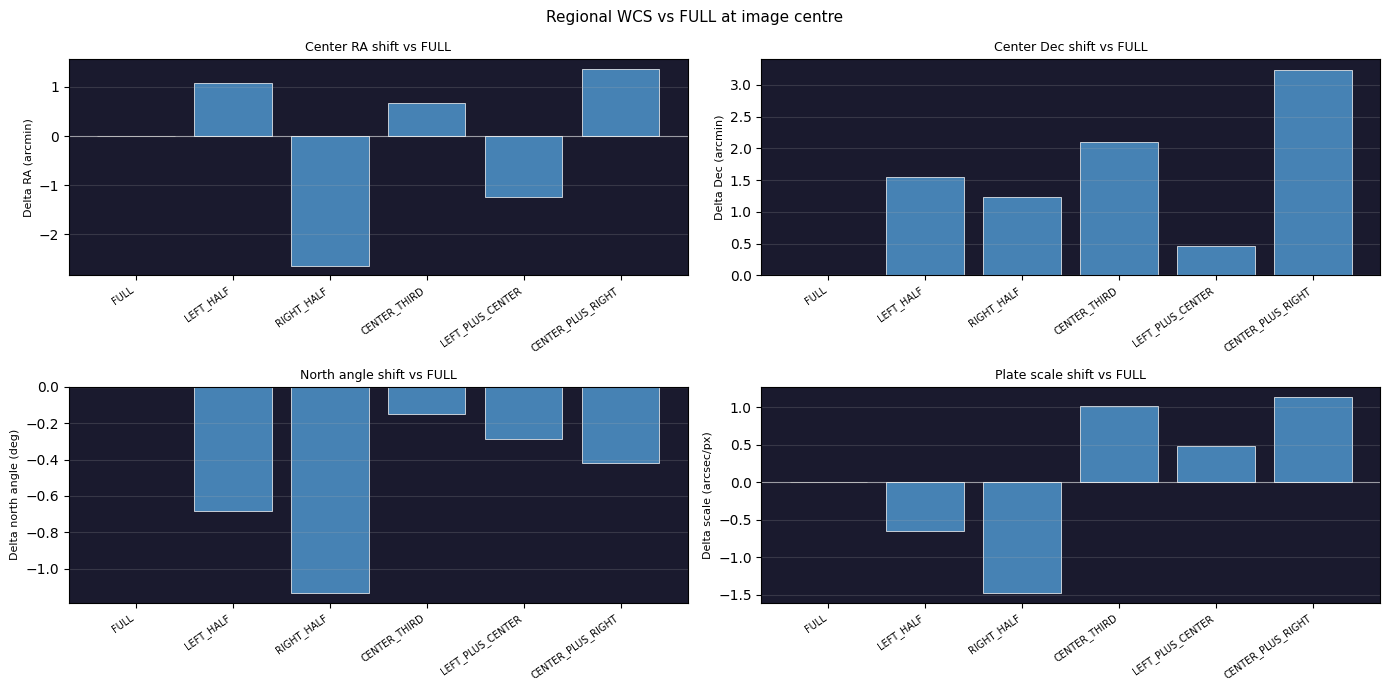

Saved wcs08_center_comparison.png


In [9]:
# For each successful regional solve, compute delta WCS values vs FULL
# and plot as grouped bar charts.

names_ok  = [n for n in REGION_MASKS if regional_results.get(n) is not None]
dra_vals, ddec_vals, dnorth_vals, dscale_vals = [], [], [], []

for name in names_ok:
    res = regional_results[name]
    try:
        ra, dec, north, scale = _wcs_center(res)
        dra_vals.append((ra  - ref_ra)  * np.cos(np.radians(ref_dec)) * 60)
        ddec_vals.append((dec - ref_dec) * 60)
        dnorth_vals.append(north - ref_north)
        dscale_vals.append(scale - ref_scale)
    except Exception:
        dra_vals.append(float('nan'))
        ddec_vals.append(float('nan'))
        dnorth_vals.append(float('nan'))
        dscale_vals.append(float('nan'))

fig, axes = plt.subplots(2, 2, figsize=(14, 7))
bar_kw = dict(color='steelblue', edgecolor='white', linewidth=0.5)
x_pos = np.arange(len(names_ok))

for ax, vals, ylabel, title in [
    (axes[0,0], dra_vals,    'Delta RA (arcmin)',     'Center RA shift vs FULL'),
    (axes[0,1], ddec_vals,   'Delta Dec (arcmin)',    'Center Dec shift vs FULL'),
    (axes[1,0], dnorth_vals, 'Delta north angle (deg)','North angle shift vs FULL'),
    (axes[1,1], dscale_vals, 'Delta scale (arcsec/px)','Plate scale shift vs FULL'),
]:
    ax.set_facecolor('#1a1a2e')
    bars = ax.bar(x_pos, vals, **bar_kw)
    # Colour FULL bar grey
    if 'FULL' in names_ok:
        bars[names_ok.index('FULL')].set_color('gray')
    ax.axhline(0, color='white', lw=0.8, alpha=0.5)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(names_ok, rotation=35, ha='right', fontsize=7)
    ax.set_ylabel(ylabel, fontsize=8)
    ax.set_title(title, fontsize=9)
    ax.grid(axis='y', alpha=0.2)

fig.suptitle('Regional WCS vs FULL at image centre', fontsize=11)
plt.tight_layout()
plt.savefig(OUT_DIR / 'wcs08_center_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved wcs08_center_comparison.png')

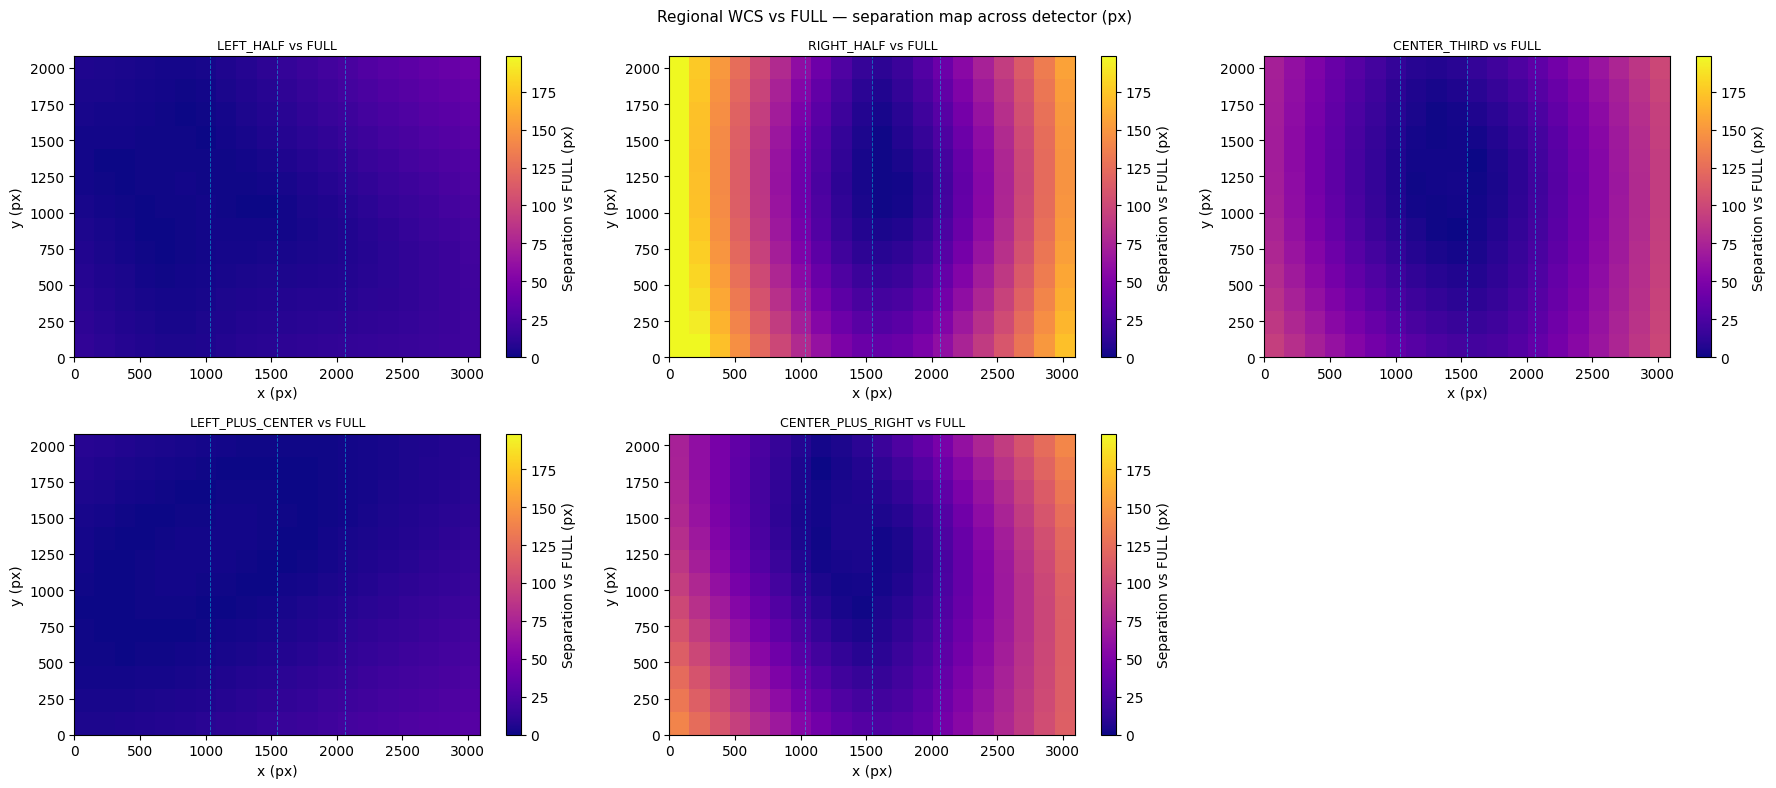

Saved wcs08_wcs_difference_maps.png


In [10]:
# On a coarse pixel grid, compute angular separation between each regional
# WCS and the FULL WCS.  Separation is expressed in pixels (arcsec / plate_scale).

_gnx, _gny = 20, 13
_gx = np.linspace(0, w - 1, _gnx)
_gy = np.linspace(0, h - 1, _gny)
_GX, _GY = np.meshgrid(_gx, _gy)
gx_flat, gy_flat = _GX.ravel(), _GY.ravel()

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    full_ra_g, full_dec_g = full_wcs.pixel_to_world_values(gx_flat, gy_flat)
full_sky_g = SkyCoord(ra=full_ra_g * u.deg, dec=full_dec_g * u.deg)

# Only plot the primary comparison set to keep the figure manageable
_plot_regions = ['LEFT_HALF', 'RIGHT_HALF', 'LEFT_THIRD',
                 'CENTER_THIRD', 'RIGHT_THIRD',
                 'LEFT_PLUS_CENTER', 'CENTER_PLUS_RIGHT']
_plot_regions = [r for r in _plot_regions if regional_results.get(r) is not None]

n_plots = len(_plot_regions)
if n_plots == 0:
    print('No successful regional solves to compare — run cell-run-solves first.')
else:
    ncols = min(3, n_plots)
    nrows = (n_plots + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows), squeeze=False)

    vmax_global = 0.0
    sep_maps = {}
    for name in _plot_regions:
        res = regional_results[name]
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            reg_wcs = WCS(res.header)
            reg_ra_g, reg_dec_g = reg_wcs.pixel_to_world_values(gx_flat, gy_flat)
        reg_sky = SkyCoord(ra=reg_ra_g * u.deg, dec=reg_dec_g * u.deg)
        sep_px = full_sky_g.separation(reg_sky).arcsec / plate_scale
        sep_maps[name] = sep_px.reshape(_gny, _gnx)
        vmax_global = max(vmax_global, np.nanpercentile(sep_px, 95))

    for ax_idx, name in enumerate(sorted(_plot_regions,
                                         key=lambda n: list(REGION_MASKS).index(n))):
        ax = axes[ax_idx // ncols][ax_idx % ncols]
        ax.set_facecolor('#111')
        im = ax.imshow(sep_maps[name], origin='lower', extent=[0, w, 0, h],
                       cmap='plasma', aspect='auto', vmin=0, vmax=vmax_global)
        plt.colorbar(im, ax=ax, label='Separation vs FULL (px)')
        for xv in [w/3, w/2, 2*w/3]:
            ax.axvline(xv, color='cyan', lw=0.7, linestyle='--', alpha=0.4)
        ax.set_title(f'{name} vs FULL', fontsize=9)
        ax.set_xlabel('x (px)'); ax.set_ylabel('y (px)')

    # Hide unused axes
    for idx in range(n_plots, nrows * ncols):
        axes[idx // ncols][idx % ncols].set_visible(False)

    fig.suptitle('Regional WCS vs FULL — separation map across detector (px)', fontsize=11)
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'wcs08_wcs_difference_maps.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved wcs08_wcs_difference_maps.png')

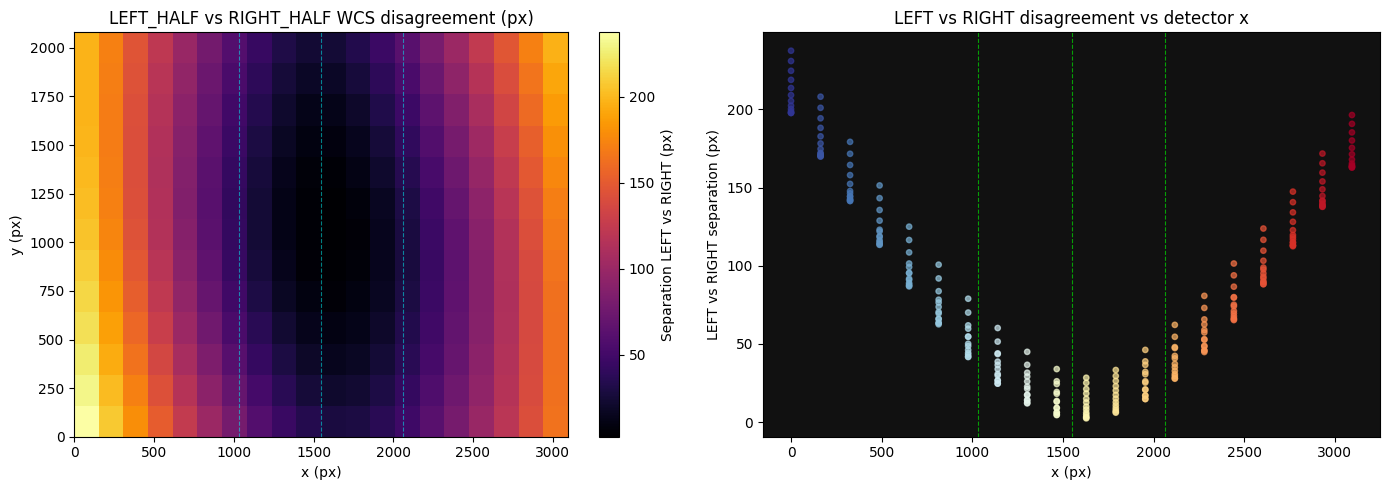

Saved wcs08_left_vs_right_wcs_difference.png

LEFT_HALF vs RIGHT_HALF disagreement by detector region:
  LEFT    : median=122.0 px  95th=211.4 px  max=237.5 px
  CENTER  : median=20.5 px  95th=44.1 px  max=60.2 px
  RIGHT   : median=97.6 px  95th=173.5 px  max=196.4 px


In [12]:
# Directly compare LEFT_HALF vs RIGHT_HALF WCS over the full detector grid.
left_res  = regional_results.get('LEFT_HALF')
right_res = regional_results.get('RIGHT_HALF')

if left_res is None or right_res is None:
    print('LEFT_HALF or RIGHT_HALF solve not available — skipping.')
else:
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        left_wcs  = WCS(left_res.header)
        right_wcs = WCS(right_res.header)
        l_ra, l_dec = left_wcs.pixel_to_world_values(gx_flat, gy_flat)
        r_ra, r_dec = right_wcs.pixel_to_world_values(gx_flat, gy_flat)

    l_sky = SkyCoord(ra=l_ra * u.deg, dec=l_dec * u.deg)
    r_sky = SkyCoord(ra=r_ra * u.deg, dec=r_dec * u.deg)
    lr_sep_px = l_sky.separation(r_sky).arcsec / plate_scale
    lr_map = lr_sep_px.reshape(_gny, _gnx)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    ax.set_facecolor('#111')
    im = ax.imshow(lr_map, origin='lower', extent=[0, w, 0, h],
                   cmap='inferno', aspect='auto')
    plt.colorbar(im, ax=ax, label='Separation LEFT vs RIGHT (px)')
    for xv in [w/3, w/2, 2*w/3]:
        ax.axvline(xv, color='cyan', lw=0.8, linestyle='--', alpha=0.5)
    ax.set_title('LEFT_HALF vs RIGHT_HALF WCS disagreement (px)')
    ax.set_xlabel('x (px)'); ax.set_ylabel('y (px)')

    ax = axes[1]
    ax.set_facecolor('#111')
    ax.scatter(gx_flat, lr_sep_px, c=gx_flat / w, cmap='RdYlBu_r', s=15, alpha=0.7)
    for xv in [w/3, w/2, 2*w/3]:
        ax.axvline(xv, color='lime', lw=0.8, linestyle='--', alpha=0.6)
    ax.set_xlabel('x (px)')
    ax.set_ylabel('LEFT vs RIGHT separation (px)')
    ax.set_title('LEFT vs RIGHT disagreement vs detector x')

    plt.tight_layout()
    plt.savefig(OUT_DIR / 'wcs08_left_vs_right_wcs_difference.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved wcs08_left_vs_right_wcs_difference.png')

    # Regional summary
    print()
    print('LEFT_HALF vs RIGHT_HALF disagreement by detector region:')
    for rname, x0, x1 in [('LEFT',   0,     w/3),
                           ('CENTER', w/3,   2*w/3),
                           ('RIGHT',  2*w/3, w)]:
        mask = (gx_flat >= x0) & (gx_flat < x1)
        vals = lr_sep_px[mask]
        print(f'  {rname:8s}: median={np.median(vals):.1f} px  '
              f'95th={np.percentile(vals, 95):.1f} px  max={vals.max():.1f} px')

In [13]:
# For each regional WCS, compute the sky-frame angle corresponding to fixed
# pixel-frame angles at representative detector positions.
# Differences show how WCS choice affects the recovered grating angle.

def pixel_to_sky_angle(wcs_obj, x, y, theta_pix_deg, step_px=5.0):
    """Sky angle (deg) for a pixel-space direction theta_pix at (x, y)."""
    tr = np.radians(theta_pix_deg)
    x2, y2 = x + step_px * np.cos(tr), y + step_px * np.sin(tr)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        ra0, dec0 = wcs_obj.pixel_to_world_values(x, y)
        ra2, dec2 = wcs_obj.pixel_to_world_values(x2, y2)
    cos_d = np.cos(np.radians((dec0 + dec2) / 2))
    return float(np.degrees(np.arctan2(dec2 - dec0, (ra2 - ra0) * cos_d)))

THETA_PIX = [0, 30, 60, 90, 120, 150]
TEST_POS  = [
    ('centre',  cx,         cy),
    ('L-mid',   w * 0.17,   cy),
    ('R-mid',   w * 0.83,   cy),
]

# Compute reference sky angles from FULL WCS
ref_angles = {}
for pos_name, tx, ty in TEST_POS:
    for th in THETA_PIX:
        ref_angles[(pos_name, th)] = pixel_to_sky_angle(full_wcs, tx, ty, th)

# Build table
_col_hdr = '  '.join(f'{t:>7}' for t in THETA_PIX)
print(f"{'Region':20s}  {'Position':8s}  {_col_hdr}")
print('-' * (35 + len(THETA_PIX) * 9))

angle_rows = []  # for CSV

for name in list(REGION_MASKS):
    res = regional_results.get(name)
    if res is None:
        continue
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        reg_wcs = WCS(res.header)
    for pos_name, tx, ty in TEST_POS:
        row_vals = []
        for th in THETA_PIX:
            sky_reg  = pixel_to_sky_angle(reg_wcs, tx, ty, th)
            sky_full = ref_angles[(pos_name, th)]
            delta    = sky_reg - sky_full
            # Wrap to (-90, 90] for axial angles
            while delta >  90: delta -= 180
            while delta <= -90: delta += 180
            row_vals.append(delta)
            angle_rows.append({'region': name, 'position': pos_name,
                                'theta_pix': th, 'delta_sky_deg': round(delta, 4)})
        _vals_str = '  '.join(f'{v:>+7.3f}' for v in row_vals)
        print(f'{name:20s}  {pos_name:8s}  {_vals_str}')
    print()

print('Table shows: delta sky angle = regional_WCS - FULL  (degrees)')
print('Positive = regional WCS rotates the recovered angle CCW vs FULL.')

# Save CSV
import csv, io
_buf = io.StringIO()
writer = csv.DictWriter(_buf, fieldnames=['region', 'position', 'theta_pix', 'delta_sky_deg'])
writer.writeheader()
writer.writerows(angle_rows)
(OUT_DIR / 'wcs08_angle_impact_table.csv').write_text(_buf.getvalue(), encoding='utf-8')
print()
print('Saved wcs08_angle_impact_table.csv')

Region                Position        0       30       60       90      120      150
-----------------------------------------------------------------------------------------
FULL                  centre     +0.000   +0.000   +0.000   +0.000   +0.000   +0.000
FULL                  L-mid      +0.000   +0.000   +0.000   +0.000   +0.000   +0.000
FULL                  R-mid      +0.000   +0.000   +0.000   +0.000   +0.000   +0.000

LEFT_HALF             centre     -0.281   +0.221   +0.637   +0.565   +0.077   -0.350
LEFT_HALF             L-mid      +0.104   -0.076   -0.218   -0.185   -0.014   +0.134
LEFT_HALF             R-mid      -0.688   +0.520   +1.321   +1.129   +0.191   -0.803

RIGHT_HALF            centre     +0.260   +0.934   +1.193   +0.800   +0.137   -0.144
RIGHT_HALF            L-mid      +3.420   +7.122   +6.409   +2.800   -0.530   -0.620
RIGHT_HALF            R-mid      -0.551   -2.631   -1.705   +0.966   +3.036   +2.465

CENTER_THIRD          centre     -0.304   -0.401   -0.063

In [14]:
import csv, io as _io

rows = []
for name in REGION_MASKS:
    res = regional_results.get(name)
    mask = REGION_MASKS[name]
    n_src = int(mask.sum())
    if res is None:
        rows.append({'region': name, 'n_src': n_src, 'status': 'FAILED',
                     'sub_id': '', 'job_id': '', 'ra': '', 'dec': '',
                     'north_deg': '', 'scale_as_px': '', 'sip': '', 'n_corr': ''})
        continue
    n_corr = len(res.corr_table) if res.corr_table is not None else 0
    sip = 'Y' if has_sip(res.header) else 'N'
    try:
        ra, dec, north, scale = _wcs_center(res)
    except Exception:
        ra = dec = north = scale = float('nan')
    rows.append({'region': name, 'n_src': n_src, 'status': 'OK',
                 'sub_id': res.submission_id, 'job_id': res.job_id,
                 'ra': f'{ra:.6f}', 'dec': f'{dec:.6f}',
                 'north_deg': f'{north:.4f}', 'scale_as_px': f'{scale:.4f}',
                 'sip': sip, 'n_corr': n_corr})

_buf = _io.StringIO()
writer = csv.DictWriter(_buf, fieldnames=list(rows[0].keys()))
writer.writeheader()
writer.writerows(rows)
csv_path = OUT_DIR / 'wcs08_region_solve_summary.csv'
csv_path.write_text(_buf.getvalue(), encoding='utf-8')
print(f'Saved {csv_path.name}')

Saved wcs08_region_solve_summary.csv


## Interpretation

### A. Did left/right regional solves succeed?
A regional solve requires enough sources to uniquely identify the field. The LEFT_HALF and RIGHT_HALF solves should both work if there are enough stars (≥15–20) in each half.  RIGHT_THIRD and LEFT_THIRD may be marginal.

### B. Do regional solves have significantly different WCS centres / orientations?
Check the centre-comparison plot.  Differences of:
- **< 1 arcmin RA/Dec, < 0.1° north angle**: all solutions agree — the global WCS is fine.
- **1–10 arcmin or 0.1–1°**: moderate systematic difference — the WCS model may be   slightly wrong but usable with per-trace Jacobian correction.
- **> 10 arcmin or > 1°**: strong evidence that the full-field WCS is compromised;   a higher-order distortion model is needed.

### C/D. Does each regional solve improve its own region?
Look at the nearest-centroid table:
- If **RIGHT_HALF** reduces the right-side median distance (originally ≈ 72 px) while   increasing the left-side distance, the global WCS is sacrificing right-side accuracy   for left-side accuracy.  This is the *distortion-compromise* scenario.
- If RIGHT_HALF does **not** improve the right side, the issue is not the WCS model —   it may be source quality (spectra, artifacts) or catalog sparsity.

### E. Does the full-field solve compromise between incompatible local solutions?
Compare the LEFT vs RIGHT WCS disagreement map (plot 8):
- Large disagreement (> 5 px) that grows away from the respective solve's home region   → the detector geometry cannot be described by a single TAN-SIP projection at this FOV.
- Small disagreement everywhere → the WCS is probably fine; the edge matching issue   is not WCS-related.

### F. How large is the WCS-choice contribution to recovered angle?
Check the angle-impact table.  A delta of:
- **< 0.1°**: WCS choice has negligible effect on the science angle.
- **0.1–1°**: measurable but probably acceptable for qualitative science.
- **> 1°**: WCS choice is the dominant systematic; must choose the correct solution.

### G. Recommended next step

| Outcome | Recommendation |
|---------|----------------|
| All regional solutions agree well | Full WCS is adequate; use local Jacobian per trace |
| LEFT/RIGHT disagree at edges but centre is stable | Restrict science to central region; or fit higher-order SIP |
| Regional solutions improve their own region | Submit separate solves per science region, or use a TAN-SIP of higher order |
| Regional solves fail or are unstable | Improve source extraction (fewer spectra, brighter sources) before re-solving |
| Angle impact > 0.5° | The WCS uncertainty dominates; quantify it as a systematic error budget |
